# The below code was written by gemini
This just takes two arrays, graphs the box plot and calculates the p values for statistical significance

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
def analyze_cv_results(baseline_r2, engineered_r2, model_a_name="Baseline", model_b_name="Engineered"):
    baseline_r2 = np.array(baseline_r2)
    engineered_r2 = np.array(engineered_r2)
    
    t_stat, p_value = stats.ttest_rel(baseline_r2, engineered_r2)
    
    print("-" * 40)
    print(f"Statistical Analysis: {model_a_name} vs {model_b_name}")
    print("-" * 40)
    print(f"{model_a_name} Mean R2: {baseline_r2.mean():.4f} (std: {baseline_r2.std():.4f})")
    print(f"{model_b_name} Mean R2: {engineered_r2.mean():.4f} (std: {engineered_r2.std():.4f})")
    print(f"Paired t-test p-value: {p_value:.4g}")
    print("-" * 40)

    plt.figure(figsize=(7, 6))
    
    box_plot_data = [baseline_r2, engineered_r2]
    bp = plt.boxplot(box_plot_data, tick_labels=[model_a_name, model_b_name], patch_artist=True, widths=0.5)
    
    colors = ['white', '#dddddd']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    
    for median in bp['medians']:
        median.set(color='black', linewidth=2)
        
    for whisker in bp['whiskers']:
        whisker.set(color='black', linewidth=1.5, linestyle='--')
    for cap in bp['caps']:
        cap.set(color='black', linewidth=1.5)
        
    plt.title('Cross-Validation Stability ($R^2$ Scores)', fontsize=14, pad=20)
    plt.ylabel('$R^2$ Score', fontsize=12)
    plt.grid(axis='y', linestyle=':', alpha=0.6, color='black') # Black dotted grid
    
    plt.tight_layout()
    plt.show()

----------------------------------------
Statistical Analysis: RFR baseline vs RFR 1-3 weekly
----------------------------------------
RFR baseline Mean R2: 0.5766 (std: 0.0520)
RFR 1-3 weekly Mean R2: 0.6466 (std: 0.0412)
Paired t-test p-value: 0.007569
----------------------------------------


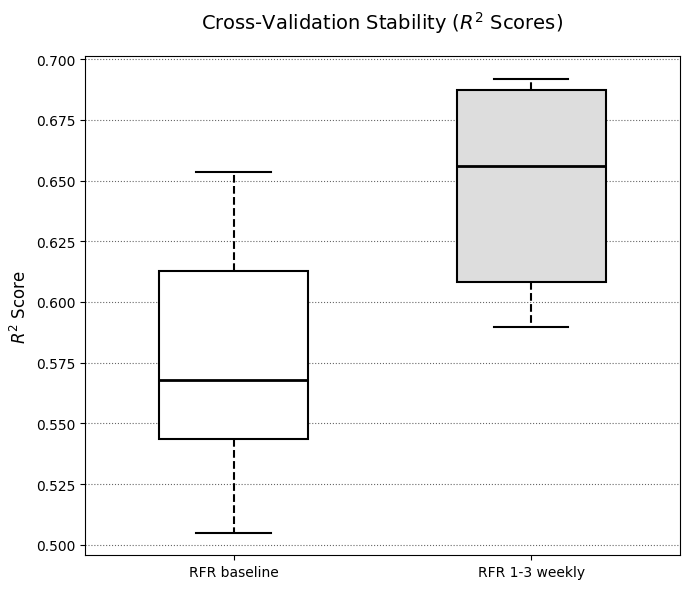

In [5]:
baseline_scores = [
    0.543475243501512,
    0.5679385957954799,
    0.6128677281021121,
    0.5050082472326765,
    0.653607684446442,
]
history_added_scores = [
    0.6560491951403897,
    0.6082048867858212,
    0.6873636988914872,
    0.5896612791263306,
    0.6917548091872129,
]

analyze_cv_results(
    baseline_r2=baseline_scores,
    engineered_r2=history_added_scores,
    model_a_name="RFR baseline",
    model_b_name="RFR 1-3 weekly",
)

----------------------------------------
Statistical Analysis: RFR baseline vs RFR 1-3 daily
----------------------------------------
RFR baseline Mean R2: 0.5766 (std: 0.0520)
RFR 1-3 daily Mean R2: 0.6344 (std: 0.0359)
Paired t-test p-value: 0.01255
----------------------------------------


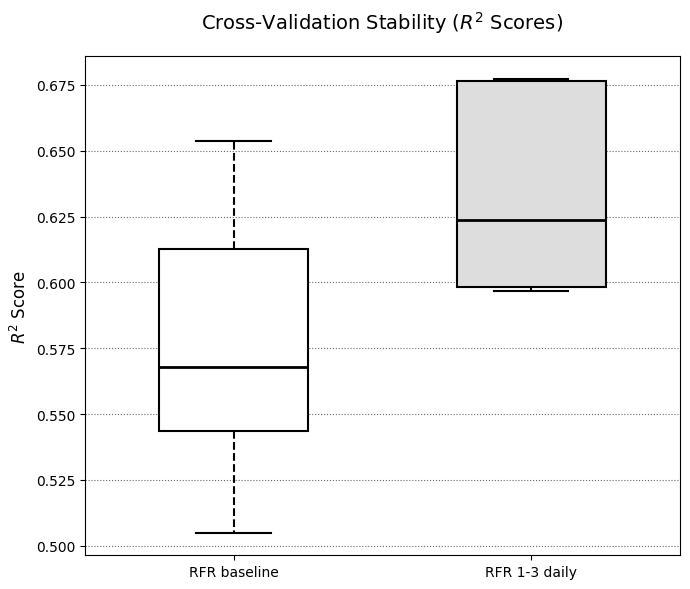

In [7]:
baseline_scores = [
    0.543475243501512,
    0.5679385957954799,
    0.6128677281021121,
    0.5050082472326765,
    0.653607684446442,
]
history_added_scores = [
    0.6236160630525538,
    0.5982992527629883,
    0.676416952539405,
    0.596670930421102,
    0.6771732862098059,
]

analyze_cv_results(
    baseline_r2=baseline_scores,
    engineered_r2=history_added_scores,
    model_a_name="RFR baseline",
    model_b_name="RFR 1-3 daily",
)